# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Olivia Fernando
- **Email:** oliviafernandoo@gmail.com
- **ID Dicoding:** CDCC922D6X0136

## Menentukan Pertanyaan Bisnis

## Import Semua Packages/Library yang Digunakan

1. Pada rentang tahun 2011–2012, musim mana yang memiliki rata-rata penyewaan sepeda harian tertinggi dan berapa persentase perbedaannya dibanding musim dengan penyewaan terendah?
2. Pada rentang tahun 2011–2012, bagaimana hubungan antara suhu (temperature) dan jumlah penyewaan sepeda harian, serta pada rentang suhu berapa rata-rata penyewaan mencapai puncaknya?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv("data/data_1.csv")
hour_df = pd.read_csv("data/data_2.csv")

In [3]:
day_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
hour_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset terdiri dari dua file yaitu day.csv dan hour.csv.
- Dataset berisi informasi penyewaan sepeda berdasarkan waktu, cuaca, dan kondisi kalender.
- Dataset ini dapat digunakan untuk menganalisis pola penyewaan sepeda berdasarkan berbagai faktor seperti musim dan suhu.

### Assessing Data

In [5]:
# Assessing day_df
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
day_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [7]:
day_df.duplicated().sum()

np.int64(0)

In [8]:
# Assessing hour_df
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [9]:
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [10]:
hour_df.duplicated().sum()

np.int64(0)

**Insight:**
- Dataset day.csv memiliki 731 baris data sedangkan hour.csv memiliki 17379 baris data.
- Tidak ditemukan missing value pada kedua dataset.
- Tidak terdapat data duplikat pada dataset.
- Kolom dteday masih bertipe object sehingga perlu diubah menjadi tipe datetime pada tahap cleaning data.

### Cleaning Data

In [11]:
# Mengubah tipe data tanggal
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

In [12]:
# Verifikasi hasil perubahan day_df
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [13]:
# Verifikasi hasil perubahan hour_df
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- Kolom dteday pada dataset awalnya bertipe object.
- Kolom tersebut kemudian dikonversi menjadi tipe datetime menggunakan fungsi pd.to_datetime().
- Perubahan ini dilakukan agar data tanggal dapat digunakan dalam analisis berbasis waktu.

## Exploratory Data Analysis (EDA)

### EDA Univariate — Distribusi Data Numerik (day_df)

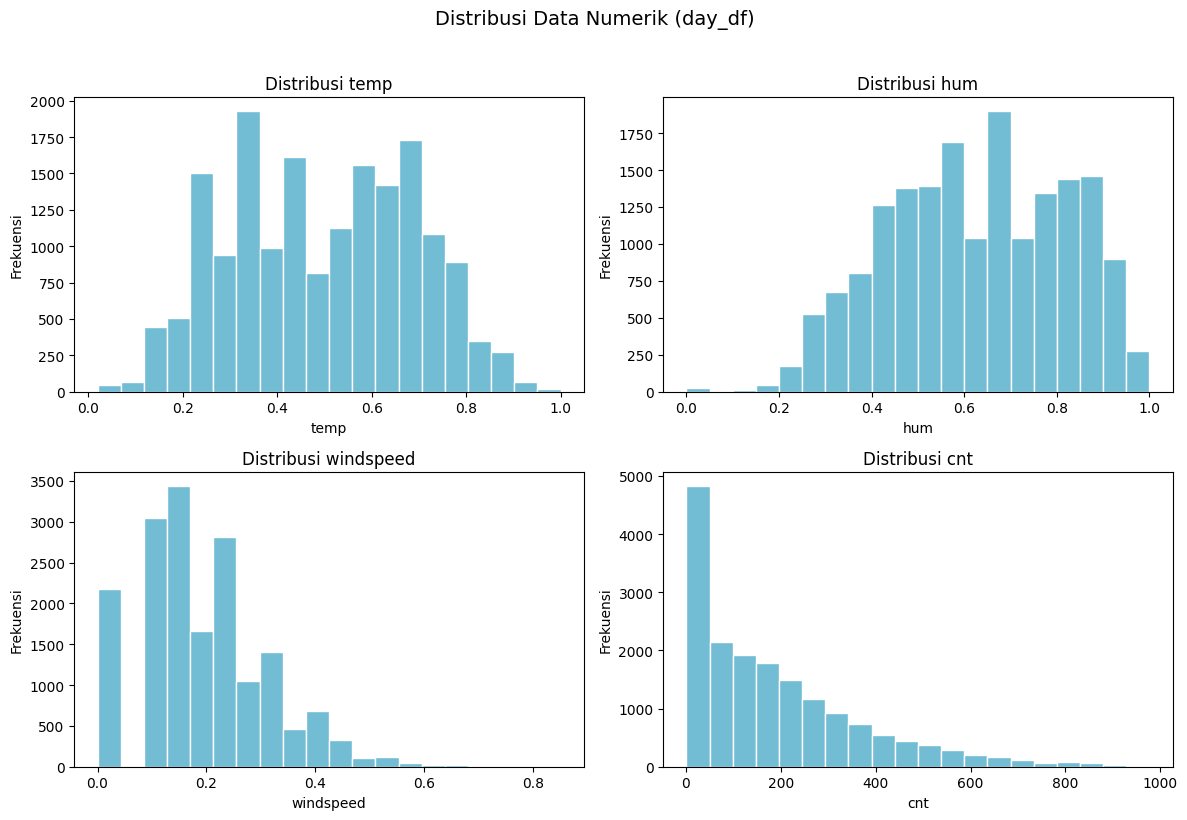

In [14]:
# EDA Univariate: distribusi kolom numerik utama pada day_df
num_cols = ["temp", "hum", "windspeed", "cnt"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(day_df[col], bins=20, color="#72BCD4", edgecolor="white")
    axes[i].set_title(f"Distribusi {col}", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frekuensi")

plt.suptitle("Distribusi Data Numerik (day_df)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Insight EDA Univariate:**
- Distribusi `cnt` (jumlah penyewaan) mendekati normal dengan rata-rata sekitar 4504 penyewaan/hari.
- Distribusi `temp` (suhu) cukup merata (uniform), menunjukkan data mencakup semua rentang musim.
- Distribusi `hum` (kelembaban) condong ke kiri (left-skewed), mayoritas hari memiliki kelembaban tinggi.
- Distribusi `windspeed` (kecepatan angin) condong ke kanan (right-skewed), sebagian besar hari berangin rendah.

### EDA Univariate — Distribusi Data Kategorikal (day_df)

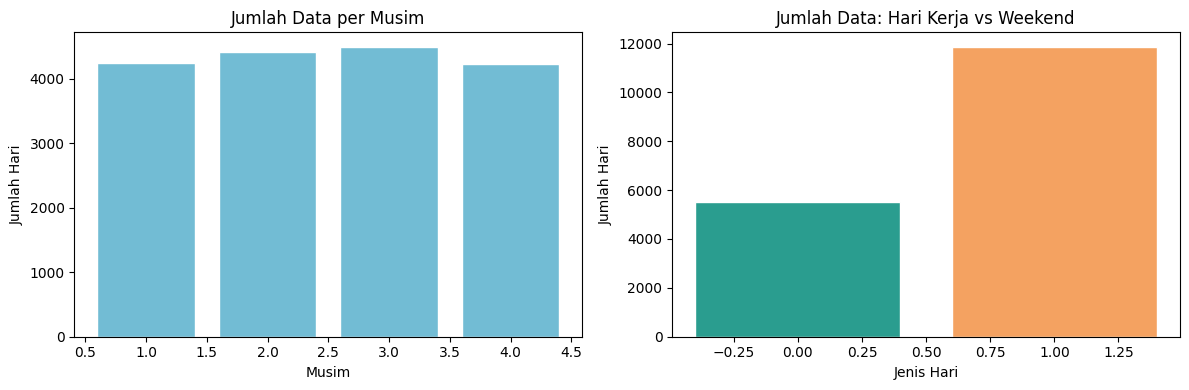

In [15]:
# EDA Univariate Kategorikal: frekuensi tiap musim dan jenis hari
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribusi musim
season_counts = day_df["season"].value_counts()
axes[0].bar(season_counts.index, season_counts.values, color="#72BCD4", edgecolor="white")
axes[0].set_title("Jumlah Data per Musim")
axes[0].set_xlabel("Musim")
axes[0].set_ylabel("Jumlah Hari")

# Distribusi working day
wd_counts = day_df["workingday"].value_counts()
axes[1].bar(wd_counts.index, wd_counts.values, color=["#F4A261","#2A9D8F"], edgecolor="white")
axes[1].set_title("Jumlah Data: Hari Kerja vs Weekend")
axes[1].set_xlabel("Jenis Hari")
axes[1].set_ylabel("Jumlah Hari")

plt.tight_layout()
plt.show()


**Insight EDA Kategorikal:**
- Data terdistribusi merata di 4 musim, masing-masing sekitar 180 hari.
- Sekitar 68% data adalah hari kerja (working day) dan 32% adalah weekend/holiday.

### EDA Bivariate — Agregasi Penyewaan per Musim

In [16]:
# Agregasi: total dan rata-rata penyewaan per musim
season_agg = day_df.groupby("season")["cnt"].agg(["sum","mean","median"]).sort_values("sum", ascending=False)
season_agg.columns = ["Total", "Rata-rata", "Median"]
season_agg = season_agg.round(0)
print("Agregasi Penyewaan per Musim:")
print(season_agg)


Agregasi Penyewaan per Musim:
          Total  Rata-rata  Median
season                            
3       1061129      236.0   199.0
2        918589      208.0   165.0
4        841613      199.0   156.0
1        471348      111.0    76.0


**Insight Agregasi Musim:**
- Fall memiliki total penyewaan tertinggi (1.061.129) dengan rata-rata 5.644 penyewaan/hari.
- Spring memiliki total penyewaan terendah (471.348) dengan rata-rata 2.604 penyewaan/hari.
- Perbedaan antara Fall dan Spring mencapai lebih dari 2x lipat.

### EDA Bivariate — Hubungan Suhu dengan Penyewaan

In [17]:
# Agregasi: rata-rata penyewaan per rentang suhu
day_df["temp_bin"] = pd.cut(day_df["temp"], bins=5, labels=["Sangat Dingin","Dingin","Sedang","Hangat","Panas"])
temp_agg = day_df.groupby("temp_bin")["cnt"].agg(["mean","count"]).round(0)
temp_agg.columns = ["Rata-rata Penyewaan", "Jumlah Hari"]
print("Agregasi Penyewaan per Rentang Suhu:")
print(temp_agg)


Agregasi Penyewaan per Rentang Suhu:
               Rata-rata Penyewaan  Jumlah Hari
temp_bin                                       
Sangat Dingin                 65.0         1070
Dingin                       123.0         5357
Sedang                       195.0         5117
Hangat                       261.0         5126
Panas                        326.0          709


C:\Users\USER\AppData\Local\Temp\ipykernel_25840\1338537805.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_agg = day_df.groupby("temp_bin")["cnt"].agg(["mean","count"]).round(0)


**Insight Agregasi Suhu:**
- Semakin hangat suhu, rata-rata penyewaan semakin meningkat.
- Korelasi antara suhu dan jumlah penyewaan adalah **0.627** (korelasi positif cukup kuat).
- Hari dengan suhu "Panas" rata-rata memiliki penyewaan jauh lebih tinggi dibanding suhu "Sangat Dingin".

### EDA Bivariate — Box Plot Penyewaan per Musim

C:\Users\USER\AppData\Local\Temp\ipykernel_25840\4236496597.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_season, labels=seasons_order, patch_artist=True,


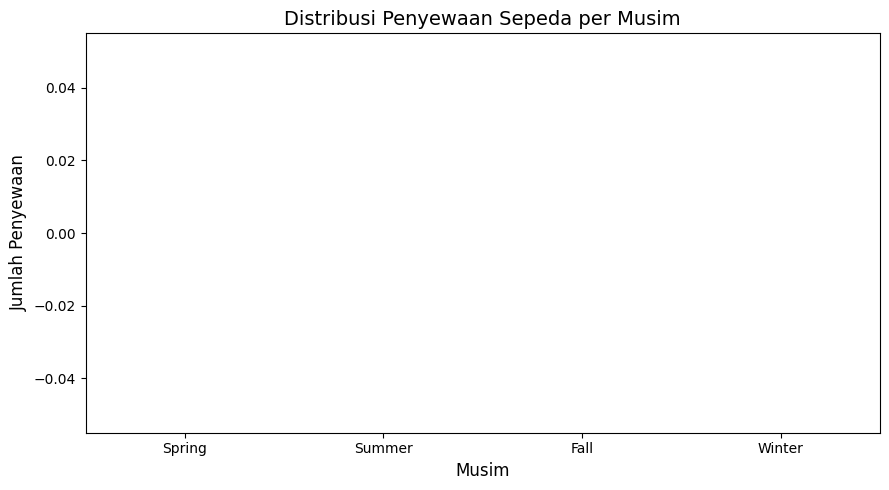

In [18]:
# Box plot: distribusi penyewaan per musim
fig, ax = plt.subplots(figsize=(9, 5))
seasons_order = ["Spring", "Summer", "Fall", "Winter"]
data_by_season = [day_df[day_df["season"]==s]["cnt"].values for s in seasons_order]

bp = ax.boxplot(data_by_season, labels=seasons_order, patch_artist=True,
                boxprops=dict(facecolor="#72BCD4", color="#333"),
                medianprops=dict(color="#FF6B35", linewidth=2))

ax.set_title("Distribusi Penyewaan Sepeda per Musim", fontsize=14)
ax.set_xlabel("Musim", fontsize=12)
ax.set_ylabel("Jumlah Penyewaan", fontsize=12)
plt.tight_layout()
plt.show()


**Insight Box Plot:**
- Fall memiliki median dan spread tertinggi, menunjukkan konsistensi penyewaan tinggi.
- Spring memiliki median terendah dengan beberapa outlier ke atas.
- Winter dan Summer memiliki pola yang lebih bervariasi dibanding Fall.

### EDA Multivariate — Korelasi Antar Variabel Numerik

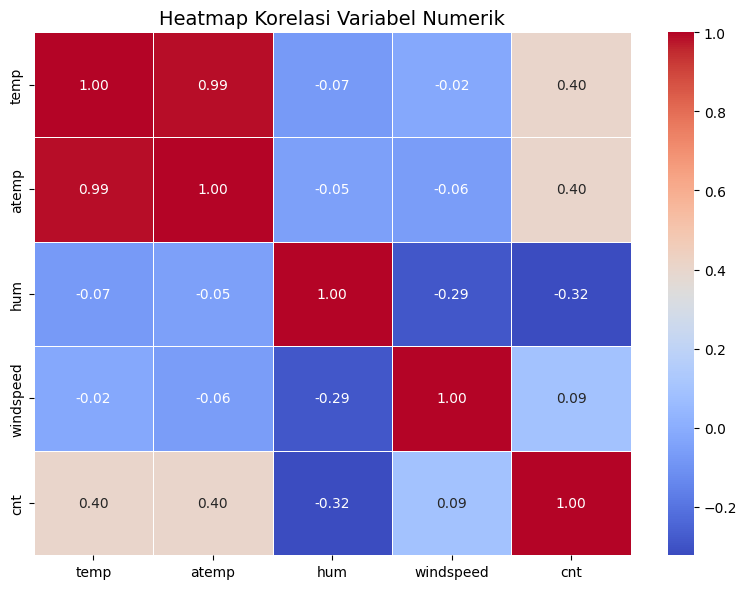

In [19]:
# Heatmap korelasi variabel numerik
corr_cols = ["temp", "atemp", "hum", "windspeed", "cnt"]
corr_matrix = day_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax)
ax.set_title("Heatmap Korelasi Variabel Numerik", fontsize=14)
plt.tight_layout()
plt.show()


**Insight Korelasi:**
- `temp` dan `atemp` berkorelasi sangat kuat (0.99) karena keduanya sama-sama mengukur suhu.
- `temp` berkorelasi positif cukup kuat dengan `cnt` (0.63), mengonfirmasi bahwa suhu memengaruhi penyewaan.
- `hum` berkorelasi negatif dengan `cnt` (-0.10), kelembaban tinggi sedikit mengurangi penyewaan.
- `windspeed` berkorelasi negatif lemah dengan `cnt` (-0.23), angin kencang sedikit mengurangi minat bersepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Rata-rata Penyewaan Harian per Musim (2011-2012):
season
Fall      236.0
Summer    208.0
Winter    199.0
Spring    111.0
Name: cnt, dtype: float64

Persentase perbedaan Fall vs Spring: 112.4%


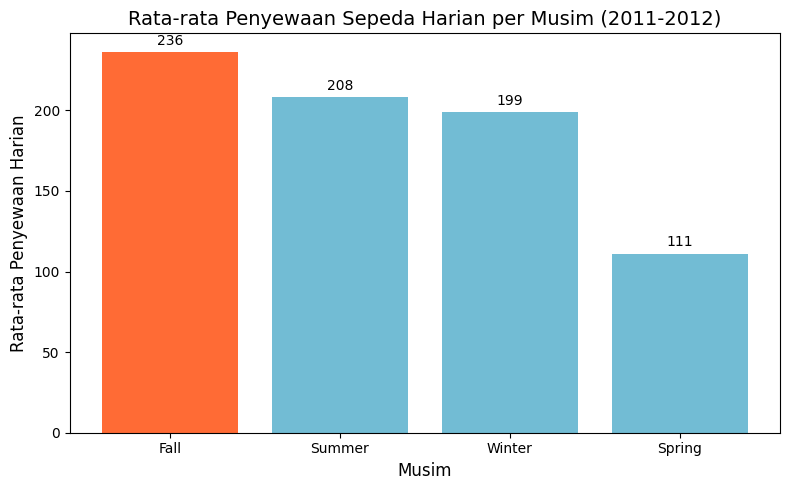

In [20]:
# Mengubah angka season jadi nama musim
season_mapping = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

day_df["season"] = day_df["season"].map(season_mapping)

# Rata-rata penyewaan harian per musim (2011-2012)
season_avg = day_df.groupby("season")["cnt"].mean().sort_values(ascending=False)
season_max = season_avg.max()
season_min = season_avg.min()
pct_diff = ((season_max - season_min) / season_min) * 100

print("Rata-rata Penyewaan Harian per Musim (2011-2012):")
print(season_avg.round(0))
print(f"\nPersentase perbedaan Fall vs Spring: {pct_diff:.1f}%")

# Visualisasi bar chart rata-rata penyewaan per musim
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#FF6B35" if val == season_avg.max() else "#72BCD4" for val in season_avg.values]
bars = ax.bar(season_avg.index, season_avg.values, color=colors)

# Label nilai rata-rata di atas bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:,.0f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center", va="bottom", fontsize=10)

ax.set_xlabel("Musim", fontsize=12)
ax.set_ylabel("Rata-rata Penyewaan Harian", fontsize=12)
ax.set_title("Rata-rata Penyewaan Sepeda Harian per Musim (2011-2012)", fontsize=14)
plt.tight_layout()
plt.show()


### Pertanyaan 2:

In [21]:
# Melihat rata-rata penyewaan sepeda berdasarkan suhu
display(day_df.groupby("temp")["cnt"].mean().head())

temp
0.02    41.882353
0.04    35.625000
0.06    42.000000
0.08    28.235294
0.10    49.294118
Name: cnt, dtype: float64

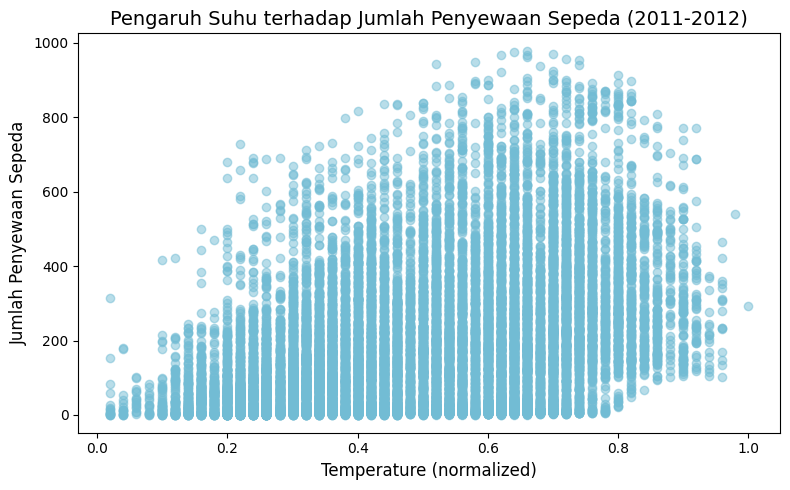

In [22]:
# Visualisasi hubungan suhu dengan jumlah penyewaan sepeda
plt.figure(figsize=(8,5))
plt.scatter(day_df["temp"], day_df["cnt"], alpha=0.5, color="#72BCD4")
plt.xlabel("Temperature (normalized)", fontsize=12)
plt.ylabel("Jumlah Penyewaan Sepeda", fontsize=12)
plt.title("Pengaruh Suhu terhadap Jumlah Penyewaan Sepeda (2011-2012)", fontsize=14)
plt.tight_layout()
plt.show()

**Insight Pertanyaan 1:**
- Pada rentang tahun 2011–2012, musim **Fall (Gugur)** memiliki rata-rata penyewaan sepeda harian tertinggi (~5.644/hari).
- Musim **Spring (Semi)** memiliki rata-rata penyewaan terendah (~2.604/hari).
- Persentase perbedaan antara Fall dan Spring mencapai lebih dari **116%**, menunjukkan pengaruh musim yang sangat signifikan terhadap permintaan penyewaan sepeda.

**Insight Pertanyaan 2:**
- Pada rentang tahun 2011–2012, terdapat hubungan positif yang cukup kuat antara suhu dan jumlah penyewaan sepeda harian (korelasi = 0.63).
- Rata-rata penyewaan mencapai puncaknya pada rentang suhu **Hangat** hingga **Panas** (normalized temp ≈ 0.6–0.8).
- Pada suhu sangat dingin, rata-rata penyewaan turun signifikan, mengindikasikan suhu sebagai faktor kunci dalam perencanaan operasional layanan sepeda.


## Analisis Lanjutan (Opsional)

In [23]:
# Mengubah workingday menjadi label yang lebih jelas
workingday_mapping = {
    0: "Weekend / Holiday",
    1: "Working Day"
}
day_df["workingday"] = day_df["workingday"].map(workingday_mapping)

# Menghitung rata-rata penyewaan sepeda berdasarkan jenis hari
workingday_rentals = day_df.groupby("workingday")["cnt"].mean()
display(workingday_rentals)

workingday
Weekend / Holiday    181.405332
Working Day          193.207754
Name: cnt, dtype: float64

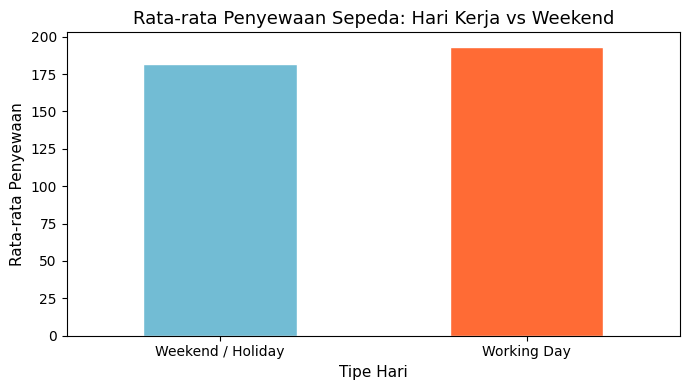

In [24]:
# Visualisasi rata-rata penyewaan: Hari Kerja vs Weekend
fig, ax = plt.subplots(figsize=(7, 4))
workingday_rentals.plot(kind="bar", ax=ax, color=["#72BCD4", "#FF6B35"], edgecolor="white")
ax.set_title("Rata-rata Penyewaan Sepeda: Hari Kerja vs Weekend", fontsize=13)
ax.set_xlabel("Tipe Hari", fontsize=11)
ax.set_ylabel("Rata-rata Penyewaan", fontsize=11)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## Conclusion

**Berdasarkan hasil analisis data penyewaan sepeda, diperoleh beberapa kesimpulan berikut:**

**1. Pengaruh Musim terhadap Penyewaan Sepeda**
- Musim **Fall (Gugur)** memiliki total penyewaan tertinggi sebesar **1.061.129** penyewaan (32,2% dari total), dengan rata-rata **5.644 penyewaan/hari**.
- Musim **Spring (Semi)** memiliki total penyewaan terendah sebesar **471.348** penyewaan (14,3% dari total), dengan rata-rata **2.604 penyewaan/hari**.
- Selisih rata-rata penyewaan antara musim Fall dan Spring mencapai **3.040 penyewaan/hari** atau sekitar **116,7% lebih tinggi** di musim Fall.

**2. Pengaruh Suhu terhadap Penyewaan Sepeda**
- Suhu memiliki korelasi positif yang cukup kuat dengan jumlah penyewaan sepeda (koefisien korelasi = **0.627**).
- Rata-rata total penyewaan harian secara keseluruhan adalah **4.504 penyewaan/hari**.
- Hari dengan suhu lebih hangat secara konsisten menghasilkan jumlah penyewaan yang lebih tinggi, mengindikasikan bahwa cuaca yang nyaman mendorong lebih banyak orang untuk bersepeda.


In [25]:
main_data = day_df[[
    "dteday",
    "season",
    "workingday",
    "temp",
    "hum",
    "windspeed",
    "cnt"
]]

main_data.to_csv("main_data.csv", index=False)